# Employee Salary Prediction Project

### Required Library and Read CSV file

In [430]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.tree import DecisionTreeRegressor

In [431]:
df = pd.read_csv("../data/employee_salary_project.csv")

### Load and inspect

In [432]:
print(df.head())
print()
print(df.tail())
print()
print(df.shape)
print()
print(df.dtypes)

   Employee_ID        Name Department Education       City Remote_Work   Age  \
0         1001  Employee_1        Web  Bachelor  Hyderabad         Yes  58.0   
1         1002  Employee_2       Data  Bachelor      Delhi          No  23.0   
2         1003  Employee_3         AI  Bachelor  Bengaluru         Yes  44.0   
3         1004  Employee_4         AI  Bachelor  Hyderabad          No  41.0   
4         1005  Employee_5      Cloud    Master      Delhi         Yes  30.0   

   Experience  Projects  Performance    Salary  
0          30        15        100.0  180000.0  
1           0         4         62.0   69700.0  
2          15        11         98.0  176800.0  
3          14        12         91.0  168800.0  
4           5         4         67.0  105500.0  

      Employee_ID          Name Department Education       City Remote_Work  \
1000         1796  Employee_796   Software    Master     Mumbai          No   
1001         1974  Employee_974       Data  Bachelor    Chennai   

In [433]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Employee_ID  1005 non-null   int64  
 1   Name         1005 non-null   object 
 2   Department   990 non-null    object 
 3   Education    994 non-null    object 
 4   City         1005 non-null   object 
 5   Remote_Work  1005 non-null   object 
 6   Age          995 non-null    float64
 7   Experience   1005 non-null   int64  
 8   Projects     1005 non-null   int64  
 9   Performance  990 non-null    float64
 10  Salary       995 non-null    float64
dtypes: float64(3), int64(3), object(5)
memory usage: 86.5+ KB


In [434]:
print(df.describe())

       Employee_ID         Age   Experience     Projects  Performance  \
count  1005.000000  995.000000  1005.000000  1005.000000   990.000000   
mean   1501.838806   40.447236    14.509453     9.904478    86.561616   
std     288.862289   11.554176    10.425851     5.338803    15.538716   
min    1001.000000   21.000000     0.000000     0.000000    45.000000   
25%    1252.000000   31.000000     5.000000     5.000000    73.000000   
50%    1503.000000   40.000000    14.000000    11.000000    93.000000   
75%    1752.000000   50.000000    24.000000    15.000000   100.000000   
max    2000.000000   60.000000    30.000000    15.000000   100.000000   

              Salary  
count     995.000000  
mean   145836.984925  
std     43464.293018  
min     51200.000000  
25%    109700.000000  
50%    179200.000000  
75%    180000.000000  
max    180000.000000  


In [435]:
print(df.isnull().sum())

Employee_ID     0
Name            0
Department     15
Education      11
City            0
Remote_Work     0
Age            10
Experience      0
Projects        0
Performance    15
Salary         10
dtype: int64


In [436]:
print(df.duplicated().sum())

5


In [437]:
print(df.describe(include="all"))

        Employee_ID          Name Department Education       City Remote_Work  \
count   1005.000000          1005        990       994       1005        1005   
unique          NaN          1000          5         3          6           2   
top             NaN  Employee_695         AI  Bachelor  Bengaluru         Yes   
freq            NaN             2        224       549        193         545   
mean    1501.838806           NaN        NaN       NaN        NaN         NaN   
std      288.862289           NaN        NaN       NaN        NaN         NaN   
min     1001.000000           NaN        NaN       NaN        NaN         NaN   
25%     1252.000000           NaN        NaN       NaN        NaN         NaN   
50%     1503.000000           NaN        NaN       NaN        NaN         NaN   
75%     1752.000000           NaN        NaN       NaN        NaN         NaN   
max     2000.000000           NaN        NaN       NaN        NaN         NaN   

               Age   Experi

### Data Cleaning + EDA

In [438]:
clean_df = df.copy()

In [439]:
clean_df["Department"] = clean_df["Department"].fillna(
    clean_df["Department"].mode()[0]
)

clean_df["Education"] = clean_df["Education"].fillna(
    clean_df["Education"].mode()[0]
)

clean_df["Age"] = clean_df["Age"].fillna(
    clean_df["Age"].mean()
)

clean_df["Performance"] = clean_df["Performance"].fillna(
    clean_df["Performance"].mean()
)

clean_df["Salary"] = clean_df["Salary"].fillna(
    clean_df["Salary"].median()
)

In [440]:
print(clean_df.isnull().sum())

Employee_ID    0
Name           0
Department     0
Education      0
City           0
Remote_Work    0
Age            0
Experience     0
Projects       0
Performance    0
Salary         0
dtype: int64


In [441]:
print(clean_df.duplicated().sum())

5


In [442]:
clean_df = clean_df.drop_duplicates()

In [443]:
print(clean_df.duplicated().sum())

0


In [444]:
print(clean_df.shape)
print(clean_df.dtypes)
print(clean_df.isnull().sum())

(1000, 11)
Employee_ID      int64
Name            object
Department      object
Education       object
City            object
Remote_Work     object
Age            float64
Experience       int64
Projects         int64
Performance    float64
Salary         float64
dtype: object
Employee_ID    0
Name           0
Department     0
Education      0
City           0
Remote_Work    0
Age            0
Experience     0
Projects       0
Performance    0
Salary         0
dtype: int64


In [445]:
print(clean_df.describe())

       Employee_ID          Age   Experience     Projects  Performance  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean   1500.500000    40.487472    14.552000     9.923000    86.638424   
std     288.819436    11.504596    10.432072     5.340374    15.412225   
min    1001.000000    21.000000     0.000000     0.000000    45.000000   
25%    1250.750000    31.000000     5.000000     5.000000    73.000000   
50%    1500.500000    40.447236    15.000000    12.000000    93.000000   
75%    1750.250000    50.000000    24.000000    15.000000   100.000000   
max    2000.000000    60.000000    30.000000    15.000000   100.000000   

              Salary  
count    1000.000000  
mean   146329.100000  
std     43388.033888  
min     51200.000000  
25%    110725.000000  
50%    179200.000000  
75%    180000.000000  
max    180000.000000  


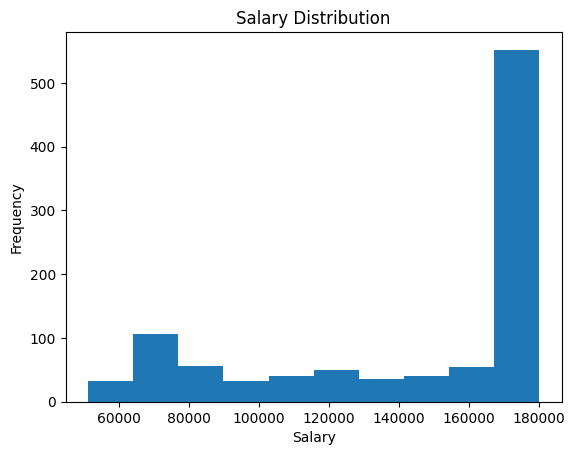

In [446]:
plt.hist(clean_df["Salary"])

plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.title("Salary Distribution")

plt.show()

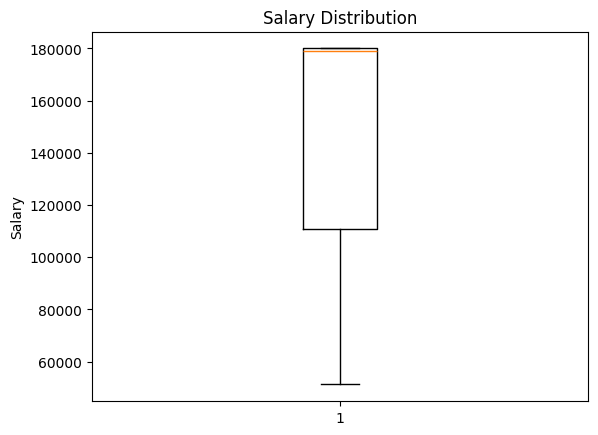

In [447]:
plt.boxplot(clean_df["Salary"])

plt.ylabel("Salary")
plt.title("Salary Distribution")

plt.show()

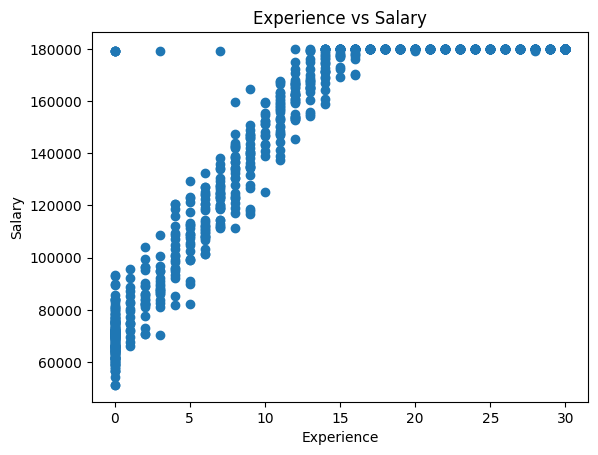

In [448]:
plt.scatter(
    clean_df["Experience"],
    clean_df["Salary"]
)

plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary")

plt.show()

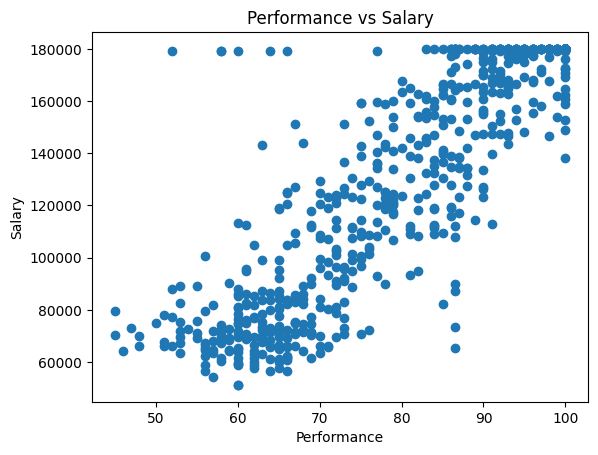

In [449]:
plt.scatter(
    clean_df["Performance"],
    clean_df["Salary"]
)

plt.xlabel("Performance")
plt.ylabel("Salary")
plt.title("Performance vs Salary")

plt.show()

In [450]:
department_summary = clean_df.groupby("Department").agg(
    Employee_Count=("Employee_ID", "count"),
    Average_Salary=("Salary", "mean"),
    Median_Salary=("Salary", "median"),
    Average_Experience=("Experience", "mean"),
    Average_Performance=("Performance", "mean")
)

department_summary = department_summary.sort_values(
    "Average_Salary",
    ascending=False
)

department_summary

,Employee_Count,Average_Salary,Median_Salary,Average_Experience,Average_Performance
Department,,,,,
Data,213,150919.718310,180000.0,16.286385,88.818637
AI,238,147643.697479,180000.0,14.676471,86.498676
Cloud,124,144665.322581,180000.0,14.483871,86.799381
Software,205,143841.951220,169200.0,13.487805,85.624991
Web,220,143717.727273,170850.0,13.768182,85.532378


In [451]:
correlation = clean_df.corr(numeric_only=True)

print(correlation)

             Employee_ID       Age  Experience  Projects  Performance  \
Employee_ID     1.000000 -0.014452   -0.011155 -0.031777    -0.038832   
Age            -0.014452  1.000000    0.959426  0.883845     0.842356   
Experience     -0.011155  0.959426    1.000000  0.924555     0.879010   
Projects       -0.031777  0.883845    0.924555  1.000000     0.900980   
Performance    -0.038832  0.842356    0.879010  0.900980     1.000000   
Salary         -0.003165  0.838395    0.872919  0.934408     0.913621   

               Salary  
Employee_ID -0.003165  
Age          0.838395  
Experience   0.872919  
Projects     0.934408  
Performance  0.913621  
Salary       1.000000  


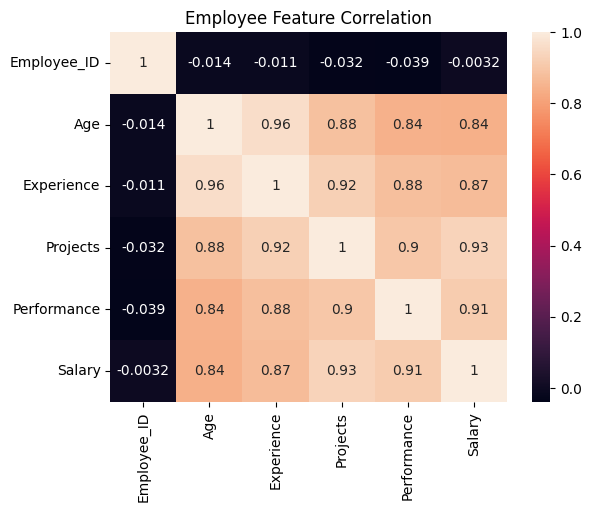

In [452]:
sns.heatmap(correlation, annot=True)

plt.title("Employee Feature Correlation")
plt.show()

In [453]:
high_experience_performers = clean_df[(clean_df["Experience"] >= 5) & (clean_df["Performance"] >= 85)].sort_values(
    "Salary",
    ascending=False
)

high_experience_performers.head()

,Employee_ID,Name,Department,Education,City,Remote_Work,Age,Experience,Projects,Performance,Salary
0,1001,Employee_1,Web,Bachelor,Hyderabad,Yes,58.0,30,15,100.0,180000.0
621,1622,Employee_622,Cloud,Bachelor,Mumbai,No,42.0,21,14,100.0,180000.0
608,1609,Employee_609,Data,Bachelor,Pune,No,58.0,28,15,100.0,180000.0
610,1611,Employee_611,Web,Master,Chennai,Yes,52.0,29,15,100.0,180000.0
612,1613,Employee_613,Cloud,Master,Pune,Yes,42.0,15,11,86.0,180000.0


In [454]:
top_10_highest_paid = clean_df.sort_values(
    "Salary",
    ascending=False
)[[
    "Name",
    "Department",
    "Experience",
    "Performance",
    "Salary"
]].head(10)

top_10_highest_paid

,Name,Department,Experience,Performance,Salary
0,Employee_1,Web,30,100.000000,180000.0
362,Employee_363,Data,20,100.000000,180000.0
360,Employee_361,Data,30,100.000000,180000.0
359,Employee_360,AI,27,100.000000,180000.0
697,Employee_698,Data,30,86.561616,180000.0
698,Employee_699,AI,23,100.000000,180000.0
356,Employee_357,Cloud,19,92.000000,180000.0
355,Employee_356,AI,18,98.000000,180000.0
354,Employee_355,AI,15,98.000000,180000.0
353,Employee_354,Data,30,100.000000,180000.0


In [455]:
high_performers = clean_df[clean_df["Performance"] >= 90].sort_values(
    "Salary",
    ascending=False
)

high_performers.head()

,Employee_ID,Name,Department,Education,City,Remote_Work,Age,Experience,Projects,Performance,Salary
0,1001,Employee_1,Web,Bachelor,Hyderabad,Yes,58.000000,30,15,100.0,180000.0
530,1531,Employee_531,Web,Bachelor,Hyderabad,No,55.000000,29,15,100.0,180000.0
578,1579,Employee_579,AI,Bachelor,Chennai,Yes,60.000000,30,15,100.0,180000.0
576,1577,Employee_577,Data,Bachelor,Bengaluru,Yes,40.447236,23,15,100.0,180000.0
916,1917,Employee_917,Cloud,Master,Delhi,No,45.000000,24,15,100.0,180000.0


### Feature Selection + ML Dataset Preparation

In [456]:
X = clean_df[[
    "Age",
    "Experience",
    "Projects",
    "Performance",
]]

y = clean_df["Salary"]

In [457]:
print(X.shape)
print(y.shape)

print(X.head())
print(y.head())

(1000, 4)
(1000,)
    Age  Experience  Projects  Performance
0  58.0          30        15        100.0
1  23.0           0         4         62.0
2  44.0          15        11         98.0
3  41.0          14        12         91.0
4  30.0           5         4         67.0
0    180000.0
1     69700.0
2    176800.0
3    168800.0
4    105500.0
Name: Salary, dtype: float64


In [458]:
print(X.isnull().sum())
print(y.isnull().sum())

Age            0
Experience     0
Projects       0
Performance    0
dtype: int64
0


In [459]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [460]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 4)
(200, 4)
(800,)
(200,)


In [461]:
baseline = DummyRegressor(strategy='mean')

baseline.fit(X_train, y_train)

baseline_prediction = baseline.predict(X_test)

In [462]:
baseline_mae = mean_absolute_error(
    y_test,
    baseline_prediction
)

baseline_rmse = root_mean_squared_error(
    y_test,
    baseline_prediction
)

baseline_r2 = r2_score(
    y_test,
    baseline_prediction
)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R2:", baseline_r2)

Baseline MAE: 38719.2325
Baseline RMSE: 43050.56916363011
Baseline R2: -0.013710969474308499


In [463]:
model = LinearRegression()

model.fit(X_train, y_train)

prediction = model.predict(X_test)

In [464]:
mae = mean_absolute_error(y_test, prediction)
rmse = root_mean_squared_error(y_test, prediction)
r2 = r2_score(y_test, prediction)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 9501.020631933447
RMSE: 14623.576917719794
R2: 0.8830329387685987


In [465]:
comparison = pd.DataFrame([
    {
        "Model": "Baseline",
        "MAE": baseline_mae,
        "RMSE": baseline_rmse,
        "R2": baseline_r2
    },
    {
        "Model": "Linear Regression",
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }
])

print(comparison)

               Model           MAE          RMSE        R2
0           Baseline  38719.232500  43050.569164 -0.013711
1  Linear Regression   9501.020632  14623.576918  0.883033


In [466]:
for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, ": ", coefficient)

print("Intercept:", model.intercept_)

Age :  142.44710914445886
Experience :  -448.2377027601139
Projects :  5249.778980859927
Performance :  1096.4456829956482
Intercept: -52.75694885352277


In [467]:
cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("CV R2 scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())
print("Std CV R2:", cv_scores.std())

CV R2 scores: [0.93974049 0.91944118 0.92892708 0.8964431  0.81260229]
Mean CV R2: 0.8994308278625676
Std CV R2: 0.04570215117890704


In [468]:
cv_mae_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="neg_mean_absolute_error"
)

print("Mean CV MAE:", -cv_mae_scores.mean())

Mean CV MAE: 8992.88462485241


In [469]:
project_summary = {
    "Features": list(X.columns),
    "Target": "Salary",
    "Training_Rows": len(X_train),
    "Testing_Rows": len(X_test),
    "Test_MAE": mae,
    "Test_RMSE": rmse,
    "Test_R2": r2,
    "Mean_CV_R2": cv_scores.mean(),
    "Mean_CV_MAE": -cv_mae_scores.mean()
}

print(project_summary)

{'Features': ['Age', 'Experience', 'Projects', 'Performance'], 'Target': 'Salary', 'Training_Rows': 800, 'Testing_Rows': 200, 'Test_MAE': 9501.020631933447, 'Test_RMSE': 14623.576917719794, 'Test_R2': 0.8830329387685987, 'Mean_CV_R2': np.float64(0.8994308278625676), 'Mean_CV_MAE': np.float64(8992.88462485241)}


### Model Improvement + Final Model Comparison

In [470]:
tree_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=5
)

tree_model.fit(X_train, y_train)

tree_prediction = tree_model.predict(X_test)

In [471]:
tree_mae = mean_absolute_error(y_test, tree_prediction)
tree_rmse = root_mean_squared_error(y_test, tree_prediction)
tree_r2 = r2_score(y_test, tree_prediction)

print("Tree MAE:", tree_mae)
print("Tree RMSE:", tree_rmse)
print("Tree R2:", tree_r2)

Tree MAE: 4164.660232690221
Tree RMSE: 10725.769829512925
Tree R2: 0.9370764383605813


In [472]:
tree_train_prediction = tree_model.predict(X_train)

tree_train_r2 = r2_score(y_train, tree_train_prediction)

print("Train R²: ", tree_train_r2)
print("Test R²:", tree_r2)

Train R²:  0.9586905919365473
Test R²: 0.9370764383605813


In [473]:
train_prediction = model.predict(X_train)

train_r2 = r2_score(y_train, train_prediction)

In [474]:
check = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "Train_R2": train_r2,
        "Test_R2": r2,
        "Test_MAE": mae,
        "Test_RMSE": rmse
    },
    {
        "Model": "Decision Tree",
        "Train_R2": tree_train_r2,
        "Test_R2": tree_r2,
        "Test_MAE": tree_mae,
        "Test_RMSE": tree_rmse
    }
])

print(check)

               Model  Train_R2   Test_R2     Test_MAE     Test_RMSE
0  Linear Regression  0.905212  0.883033  9501.020632  14623.576918
1      Decision Tree  0.958691  0.937076  4164.660233  10725.769830


In [475]:
tree_cv_scores = cross_val_score(
    tree_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

tree_cv_mae_scores = cross_val_score(
    tree_model,
    X,
    y,
    cv=5,
    scoring="neg_mean_absolute_error"
)

cv_df = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "Mean_CV_R2": cv_scores.mean(),   
        "Mean_CV_MAE": -cv_mae_scores.mean()
    },
    {
        "Model": "Decision Tree",
        "Mean_CV_R2": tree_cv_scores.mean(),   
        "Mean_CV_MAE": -tree_cv_mae_scores.mean()
    }
])

In [476]:
tree3_model = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

tree3_model.fit(X_train, y_train)

tree3_model_prediction = tree3_model.predict(X_test)

tree3_mae = mean_absolute_error(y_test, tree3_model_prediction)
tree3_rmse = root_mean_squared_error(y_test, tree3_model_prediction)
tree3_r2 = r2_score(y_test, tree3_model_prediction)

In [477]:
tree_comparision = pd.DataFrame([
    {
        "Max Depth:": 3,
        "Test R²": tree3_r2,
        "Test MAE": tree3_mae,
        "Test RMSE": tree3_rmse
    },
    {
        "Max Depth:": 5,
        "Test R²": tree_r2,
        "Test MAE": tree_mae,
        "Test RMSE": tree_rmse
    }
])

print(tree_comparision)

   Max Depth:   Test R²     Test MAE     Test RMSE
0           3  0.937735  4495.129241  10669.494222
1           5  0.937076  4164.660233  10725.769830


In [478]:
tree3_cv_scores = cross_val_score(
    tree3_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

tree3_cv_mae_scores = cross_val_score(
    tree3_model,
    X,
    y,
    cv=5,
    scoring="neg_mean_absolute_error"
)

baseline_cv_scores = cross_val_score(
    baseline,
    X,
    y,
    cv=5,
    scoring="r2"
)

baseline_cv_mae_scores = cross_val_score(
    baseline,
    X,
    y,
    cv=5,
    scoring="neg_mean_absolute_error"
)

tree3_train_prediction = tree3_model.predict(X_train)
tree3_train_r2 = r2_score(y_train, tree3_train_prediction)

baseline_train_prediction = baseline.predict(X_train)
baseline_train_r2 = r2_score(y_train, baseline_train_prediction)

In [479]:
final_comparison = pd.DataFrame([
    {
        "Model": "Baseline",
        "Train_R2": baseline_train_r2,
        "Test_R2": baseline_r2,
        "Test_MAE": baseline_mae,
        "Test_RMSE": baseline_rmse,
        "Mean_CV_R2": baseline_cv_scores.mean(),
        "Mean_CV_MAE": -baseline_cv_mae_scores.mean()
    },
    {
        "Model": "Linear Regression",
        "Train_R2": train_r2,
        "Test_R2": r2,
        "Test_MAE": mae,
        "Test_RMSE": rmse,
        "Mean_CV_R2": cv_scores.mean(),
        "Mean_CV_MAE": -cv_mae_scores.mean()
    },
    {
        "Model": "Decision Tree with max depth 3",
        "Train_R2": tree3_train_r2,
        "Test_R2": tree3_r2,
        "Test_MAE": tree3_mae,
        "Test_RMSE": tree3_rmse,
        "Mean_CV_R2": tree3_cv_scores.mean(),
        "Mean_CV_MAE": -tree3_cv_mae_scores.mean()
    },
    {
        "Model": "Decision Tree with max depth 5",
        "Train_R2": tree_train_r2,
        "Test_R2": tree_r2,
        "Test_MAE": tree_mae,
        "Test_RMSE": tree_rmse,
        "Mean_CV_R2": tree_cv_scores.mean(),
        "Mean_CV_MAE": -tree_cv_mae_scores.mean()
    }
])


### Final Model Selection + Save the Model

In [480]:
final_comparison = final_comparison.round(3)

print(final_comparison)

                            Model  Train_R2  Test_R2   Test_MAE  Test_RMSE  \
0                        Baseline     0.000   -0.014  38719.232  43050.569   
1               Linear Regression     0.905    0.883   9501.021  14623.577   
2  Decision Tree with max depth 3     0.943    0.938   4495.129  10669.494   
3  Decision Tree with max depth 5     0.959    0.937   4164.660  10725.770   

   Mean_CV_R2  Mean_CV_MAE  
0      -0.009    38449.646  
1       0.899     8992.885  
2       0.935     4911.630  
3       0.924     5119.896  


In [481]:
final_model = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

final_model.fit(X, y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [482]:
import joblib

joblib.dump(
    final_model,
    "../models/employee_salary_model.pkl"
)

['../models/employee_salary_model.pkl']